# Correlation Analysis
Pearson & Spearman correlation between numeric features and `tickets_scanned` (target variable).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1. Load & merge data
Build a master table of home matches only.

In [20]:
# Load raw match data (contains tickets_scanned + matchday + kickoff)
match = pd.read_csv('../data/raw/gold_match.csv', on_bad_lines='skip')
match = match[match['is_home_match'] == True].copy()
match['match_date'] = pd.to_datetime(match['match_date'])

# Load raw context data (weather, promotions, calendar)
context = pd.read_csv('../data/raw/gold_match_context.csv', on_bad_lines='skip')

# Load cleaned tickets (tickets_sold_total, seasonpass_holders)
tickets = pd.read_csv('../data/cleaned/gold_match_tickets_cleaned.csv')

# Load Google Trends per match
trends = pd.read_csv('../data/cleaned/match_trends.csv')

# Load pre-match press article count
buzz = pd.read_csv('../data/cleaned/match_buzz.csv')

# Merge everything on match_id
df = (
    match[['match_id', 'match_date', 'matchday', 'kickoff_time_local', 'season', 'tickets_scanned']]
    .merge(context, on='match_id', how='left')
    .merge(tickets,  on='match_id', how='left')
    .merge(trends,   on='match_id', how='left')
    .merge(buzz,     on='match_id', how='left')
)

print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
df.head(3)

Rows: 71 | Columns: 44


,match_id,match_date_x,matchday,kickoff_time_local,season,tickets_scanned,match_date_y,weather_temp_max_c,weather_temp_min_c,weather_temp_mean_c,...,is_public_holiday,public_holiday_name,is_school_holiday_flanders,school_holiday_name,pct_free_tickets,campaign_motto,tickets_sold_total,seasonpass_holders,avg_ohl_interest_7d,pre_match_article_count
0,d256yo3eng04m0fu7b4sl7wno,2022-07-30,2.0,18:15:00,2022/2023,5565.0,2022-07-30,25.8,12.9,19.8,...,False,NaN,True,Summer Holiday,13.9,NaN,5025,4032,5.165714,14.0
1,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,4.0,18:30:00,2022/2023,7440.0,2022-08-14,32.2,17.3,25.4,...,False,NaN,True,Summer Holiday,8.3,NaN,6263,4032,7.812857,48.0
2,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,6.0,18:15:00,2022/2023,4489.0,2022-08-27,21.0,15.9,18.7,...,False,NaN,True,Summer Holiday,14.8,NaN,5025,4032,8.462857,3.0


## 2. Select numeric features

In [21]:
# Select numeric columns relevant for correlation
numeric_features = [
    'matchday',
    'tickets_sold_total',
    'seasonpass_holders',
    'avg_ohl_interest_7d',
    'pre_match_article_count',
    'weather_temp_mean_c',
    'weather_rain_mm',
    'weather_windspeed_max_kmh',
    'weather_sunshine_hours',
    'weather_score',
    'promo_tickets_total',
]

# Keep only columns that exist in df
numeric_features = [c for c in numeric_features if c in df.columns]

corr_df = df[numeric_features + ['tickets_scanned']].dropna(subset=['tickets_scanned'])
print(f"Rows used for correlation: {len(corr_df)}")
print(f"Features: {numeric_features}")

Rows used for correlation: 71
Features: ['matchday', 'tickets_sold_total', 'seasonpass_holders', 'avg_ohl_interest_7d', 'pre_match_article_count', 'weather_temp_mean_c', 'weather_rain_mm', 'weather_windspeed_max_kmh', 'weather_sunshine_hours', 'weather_score', 'promo_tickets_total']


## 3. Pearson correlation
Measures **linear** relationship. Best for normally distributed features.

In [22]:
pearson_results = []

for col in numeric_features:
    subset = corr_df[['tickets_scanned', col]].dropna()
    if len(subset) < 5:
        continue
    r, p = stats.pearsonr(subset['tickets_scanned'], subset[col])
    pearson_results.append({'feature': col, 'pearson_r': round(r, 3), 'p_value': round(p, 4)})

pearson_df = pd.DataFrame(pearson_results).sort_values('pearson_r', key=abs, ascending=False)
pearson_df['significant'] = pearson_df['p_value'] < 0.05
print(pearson_df.to_string(index=False))

                  feature  pearson_r  p_value  significant
       tickets_sold_total      0.517   0.0000         True
                 matchday      0.328   0.0052         True
  pre_match_article_count      0.236   0.0544        False
   weather_sunshine_hours     -0.192   0.1081        False
      promo_tickets_total     -0.140   0.2445        False
weather_windspeed_max_kmh      0.116   0.3342        False
       seasonpass_holders      0.108   0.3689        False
      avg_ohl_interest_7d     -0.094   0.4357        False
            weather_score      0.040   0.7429        False
      weather_temp_mean_c     -0.037   0.7576        False
          weather_rain_mm     -0.035   0.7710        False


## 4. Spearman correlation
Measures **monotonic** relationship. More robust for skewed data or outliers.

In [23]:
spearman_results = []

for col in numeric_features:
    subset = corr_df[['tickets_scanned', col]].dropna()
    if len(subset) < 5:
        continue
    r, p = stats.spearmanr(subset['tickets_scanned'], subset[col])
    spearman_results.append({'feature': col, 'spearman_r': round(r, 3), 'p_value': round(p, 4)})

spearman_df = pd.DataFrame(spearman_results).sort_values('spearman_r', key=abs, ascending=False)
spearman_df['significant'] = spearman_df['p_value'] < 0.05
print(spearman_df.to_string(index=False))

                  feature  spearman_r  p_value  significant
       tickets_sold_total       0.538   0.0000         True
  pre_match_article_count       0.374   0.0018         True
                 matchday       0.332   0.0046         True
      promo_tickets_total      -0.252   0.0339         True
   weather_sunshine_hours      -0.189   0.1146        False
       seasonpass_holders       0.064   0.5966        False
      weather_temp_mean_c      -0.047   0.6982        False
          weather_rain_mm       0.039   0.7474        False
weather_windspeed_max_kmh       0.025   0.8389        False
            weather_score      -0.020   0.8710        False
      avg_ohl_interest_7d       0.008   0.9462        False


## 5. Visualisation — Pearson vs Spearman comparison

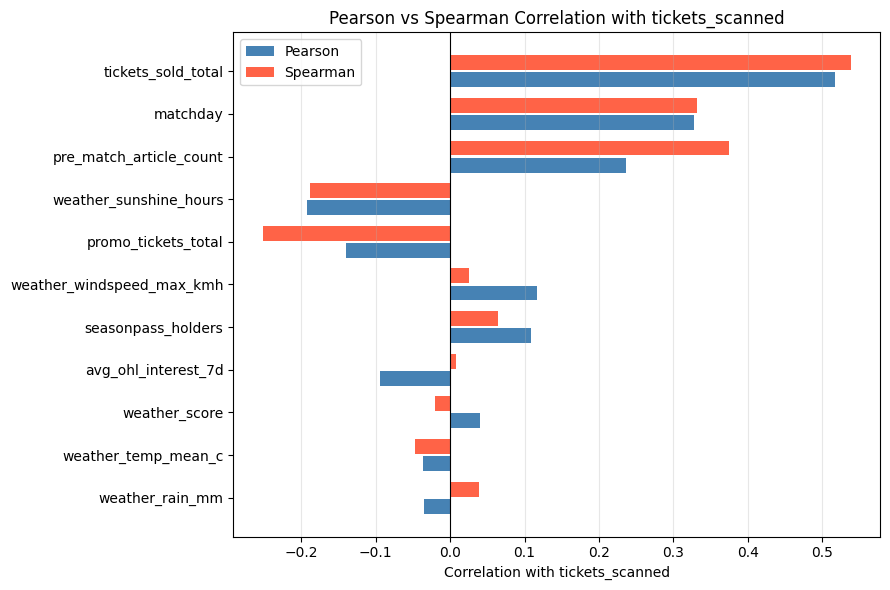

In [24]:
combined = pearson_df[['feature', 'pearson_r']].merge(
    spearman_df[['feature', 'spearman_r']], on='feature'
).sort_values('pearson_r', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

y = range(len(combined))
ax.barh([i - 0.2 for i in y], combined['pearson_r'],  height=0.35, label='Pearson',  color='steelblue')
ax.barh([i + 0.2 for i in y], combined['spearman_r'], height=0.35, label='Spearman', color='tomato')

ax.set_yticks(list(y))
ax.set_yticklabels(combined['feature'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with tickets_scanned')
ax.set_title('Pearson vs Spearman Correlation with tickets_scanned')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Scatter plots — top 4 strongest features

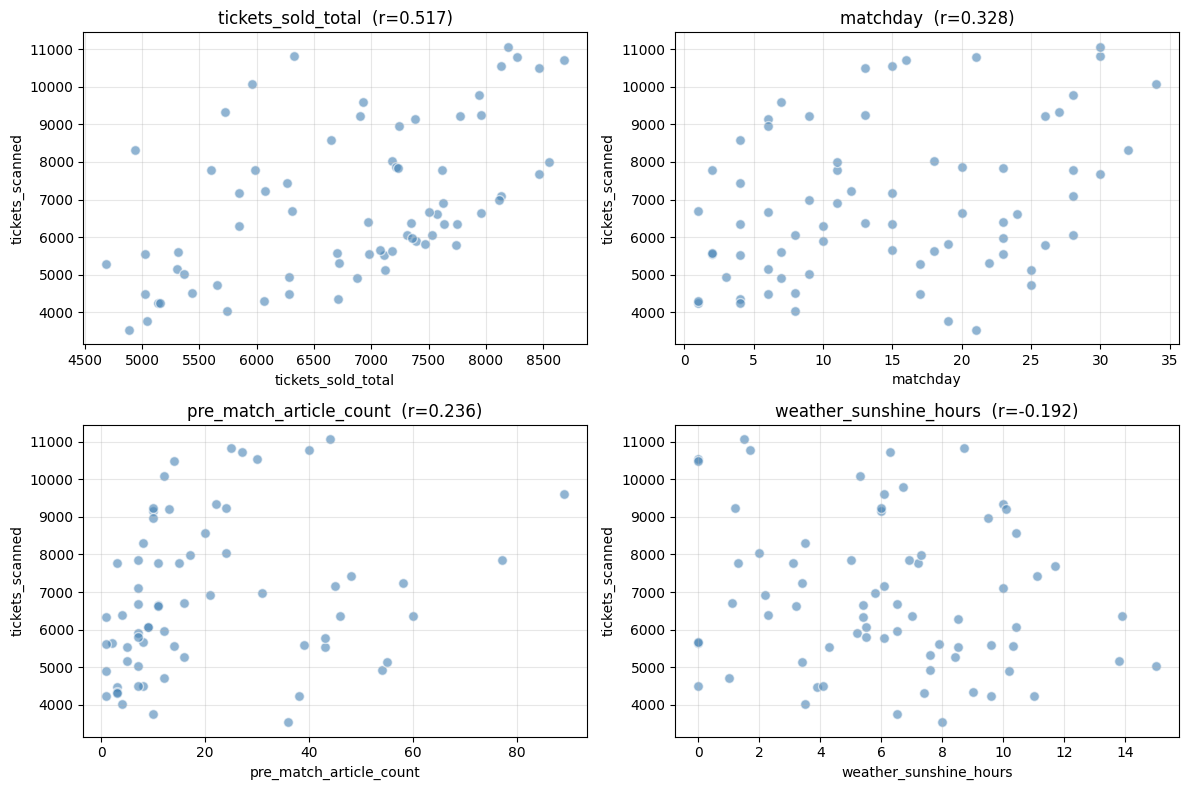

In [25]:
top4 = pearson_df.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(top4):
    subset = corr_df[['tickets_scanned', col]].dropna()
    r = pearson_df.loc[pearson_df['feature'] == col, 'pearson_r'].values[0]
    axes[i].scatter(subset[col], subset['tickets_scanned'], alpha=0.6, color='steelblue', edgecolors='white', s=50)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('tickets_scanned')
    axes[i].set_title(f'{col}  (r={r})')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Categorical features — average attendance per group
For categorical columns like `away_team` and `stage` we use group averages + ANOVA test.

**ANOVA** tests whether the differences between groups are statistically significant.
- **F-score** = how large the differences between groups are
- **p-value** < 0.05 = the category has a significant influence on attendance

In [26]:
# Add categorical columns from raw match data
cat_df = df[['match_id', 'tickets_scanned']].copy()
cat_df['away_team'] = match.set_index('match_id')['away_team'].reindex(cat_df['match_id'].values).values
cat_df['stage']     = match.set_index('match_id')['stage'].reindex(cat_df['match_id'].values).values
cat_df['season']    = match.set_index('match_id')['season'].reindex(cat_df['match_id'].values).values
cat_df['is_weekend']  = context.set_index('match_id')['is_weekend'].reindex(cat_df['match_id'].values).values
cat_df['is_school_holiday_flanders'] = context.set_index('match_id')['is_school_holiday_flanders'].reindex(cat_df['match_id'].values).values

cat_df = cat_df.dropna(subset=['tickets_scanned'])

categorical_features = ['away_team', 'stage', 'season', 'is_weekend', 'is_school_holiday_flanders']

# ANOVA per categorical feature
anova_results = []
for col in categorical_features:
    groups = [group['tickets_scanned'].dropna().values
              for _, group in cat_df.groupby(col)]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        continue
    f, p = stats.f_oneway(*groups)
    anova_results.append({'feature': col, 'F_score': round(f, 3), 'p_value': round(p, 4), 'significant': p < 0.05})

anova_df = pd.DataFrame(anova_results).sort_values('F_score', ascending=False)
print(anova_df.to_string(index=False))

                   feature  F_score  p_value  significant
                     stage   10.126   0.0022         True
                    season    5.284   0.0025         True
                 away_team    1.827   0.0568        False
                is_weekend    0.952   0.3325        False
is_school_holiday_flanders    0.010   0.9208        False


## 8. Average attendance per opponent (`away_team`)

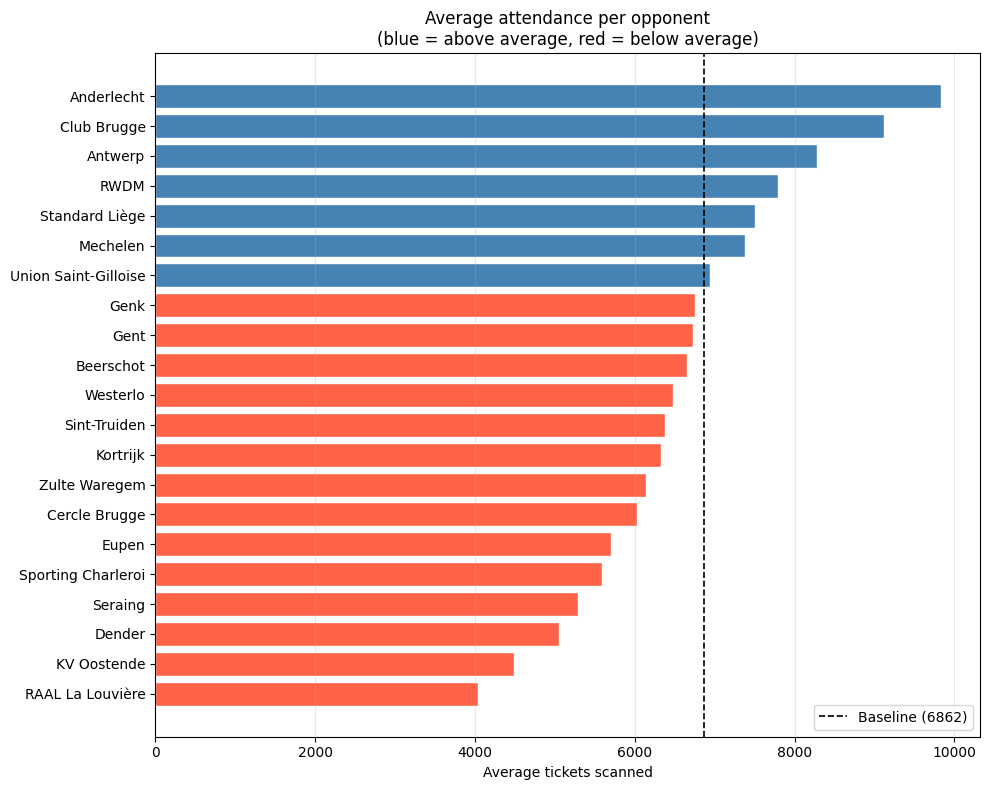

In [27]:
avg_by_opponent = (
    cat_df.groupby('away_team')['tickets_scanned']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_tickets', 'count': 'n_matches'})
    .sort_values('avg_tickets', ascending=True)
)

# Baseline = overall average
baseline = cat_df['tickets_scanned'].mean()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if v < baseline else 'steelblue' for v in avg_by_opponent['avg_tickets']]
ax.barh(avg_by_opponent.index, avg_by_opponent['avg_tickets'], color=colors, edgecolor='white')
ax.axvline(baseline, color='black', linewidth=1.2, linestyle='--', label=f'Baseline ({baseline:.0f})')
ax.set_xlabel('Average tickets scanned')
ax.set_title('Average attendance per opponent\n(blue = above average, red = below average)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Boxplots — stage, season, weekend & school holiday

C:\Users\ibenv\AppData\Local\Temp\ipykernel_29932\1486571128.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Weekday', 'Weekend'])
C:\Users\ibenv\AppData\Local\Temp\ipykernel_29932\1486571128.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['No holiday', 'School holiday'])


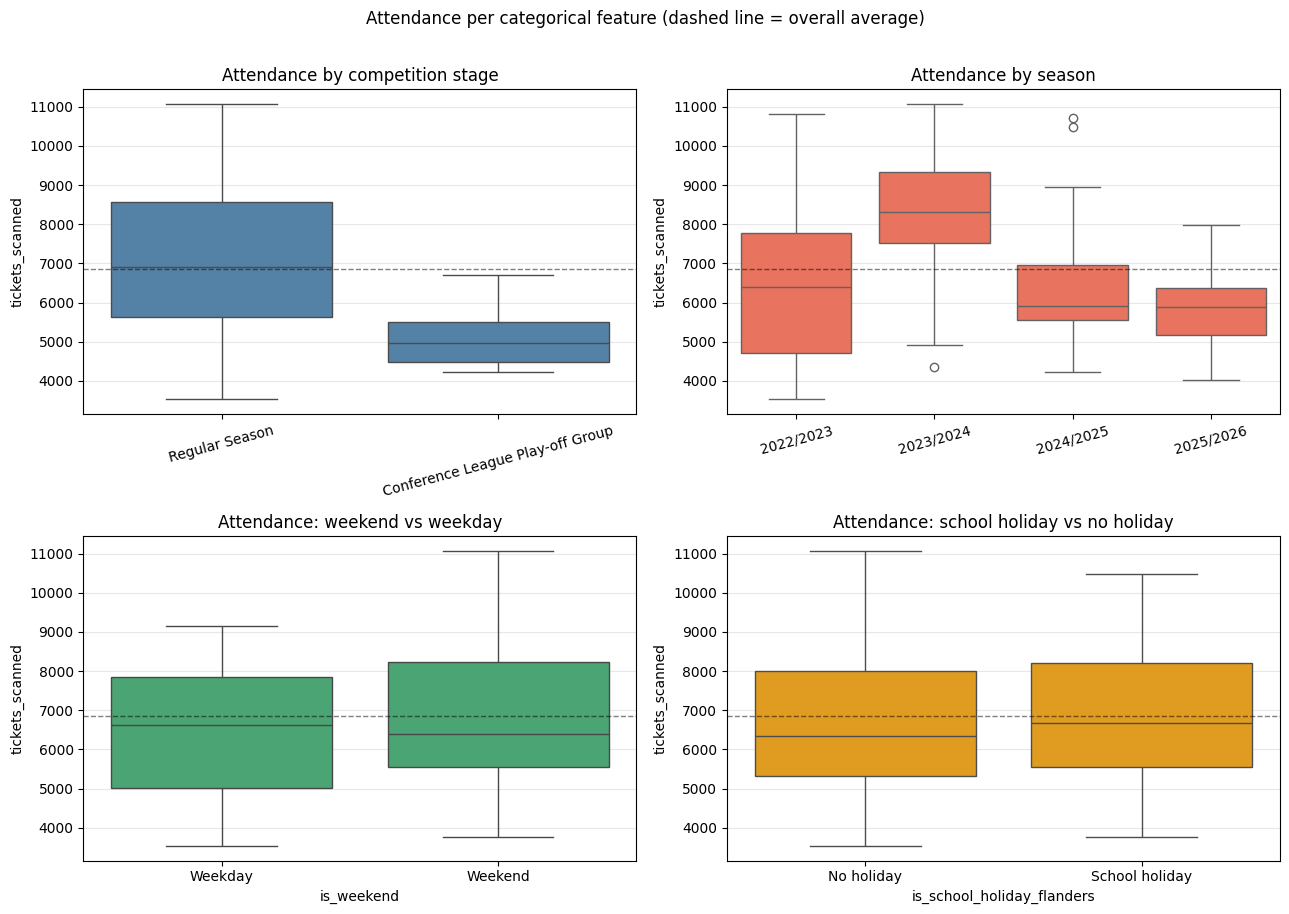

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Stage
sns.boxplot(data=cat_df, x='stage', y='tickets_scanned', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Attendance by competition stage')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=15)

# Season
sns.boxplot(data=cat_df, x='season', y='tickets_scanned', ax=axes[0, 1], color='tomato')
axes[0, 1].set_title('Attendance by season')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=15)

# Weekend vs weekday
sns.boxplot(data=cat_df, x='is_weekend', y='tickets_scanned', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Attendance: weekend vs weekday')
axes[1, 0].set_xticklabels(['Weekday', 'Weekend'])

# School holiday
sns.boxplot(data=cat_df, x='is_school_holiday_flanders', y='tickets_scanned', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Attendance: school holiday vs no holiday')
axes[1, 1].set_xticklabels(['No holiday', 'School holiday'])

for ax in axes.flatten():
    ax.axhline(baseline, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_ylabel('tickets_scanned')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Attendance per categorical feature (dashed line = overall average)', y=1.01)
plt.tight_layout()
plt.show()

## 10. VIF — Variance Inflation Factor
Detects **multicollinearity**: are some features too strongly correlated with each other?

A high VIF means a feature can largely be predicted by the other features — this confuses the model.

| VIF value | Meaning |
|---|---|
| < 5 | No problem |
| 5 – 10 | Moderate multicollinearity — watch out |
| > 10 | Severe — consider dropping the feature |

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Select only numeric features without NaN
vif_features = [
    'matchday',
    'tickets_sold_total',
    'seasonpass_holders',
    'avg_ohl_interest_7d',
    'pre_match_article_count',
    'weather_temp_mean_c',
    'weather_rain_mm',
    'weather_windspeed_max_kmh',
    'weather_sunshine_hours',
    'weather_score',
    'promo_tickets_total',
]

vif_features = [c for c in vif_features if c in df.columns]
vif_data = df[vif_features].dropna()

# Add constant (required for VIF calculation)
X_vif = add_constant(vif_data)

# Calculate VIF per feature
vif_results = pd.DataFrame({
    'feature': vif_features,
    'VIF': [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(vif_features))]
})

vif_results['VIF'] = vif_results['VIF'].round(2)
vif_results['status'] = vif_results['VIF'].apply(
    lambda v: 'SEVERE (>10)' if v > 10 else ('MODERATE (5-10)' if v > 5 else 'OK (<5)')
)

vif_results = vif_results.sort_values('VIF', ascending=False)
print(vif_results.to_string(index=False))

                  feature  VIF  status
          weather_rain_mm 2.87 OK (<5)
            weather_score 2.73 OK (<5)
                 matchday 2.55 OK (<5)
      weather_temp_mean_c 2.52 OK (<5)
       seasonpass_holders 1.80 OK (<5)
       tickets_sold_total 1.71 OK (<5)
   weather_sunshine_hours 1.49 OK (<5)
weather_windspeed_max_kmh 1.21 OK (<5)
      avg_ohl_interest_7d 1.20 OK (<5)
      promo_tickets_total 1.15 OK (<5)
  pre_match_article_count 1.11 OK (<5)


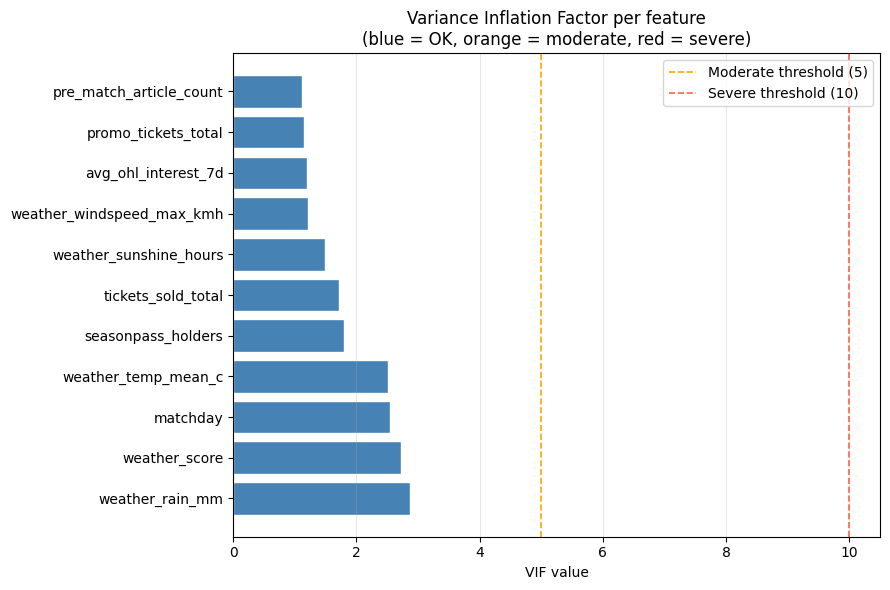

In [30]:
# Visualisation — VIF per feature
fig, ax = plt.subplots(figsize=(9, 6))

colors = [
    'tomato' if v > 10 else ('orange' if v > 5 else 'steelblue')
    for v in vif_results['VIF']
]

ax.barh(vif_results['feature'], vif_results['VIF'], color=colors, edgecolor='white')
ax.axvline(5,  color='orange', linewidth=1.2, linestyle='--', label='Moderate threshold (5)')
ax.axvline(10, color='tomato',  linewidth=1.2, linestyle='--', label='Severe threshold (10)')
ax.set_xlabel('VIF value')
ax.set_title('Variance Inflation Factor per feature\n(blue = OK, orange = moderate, red = severe)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

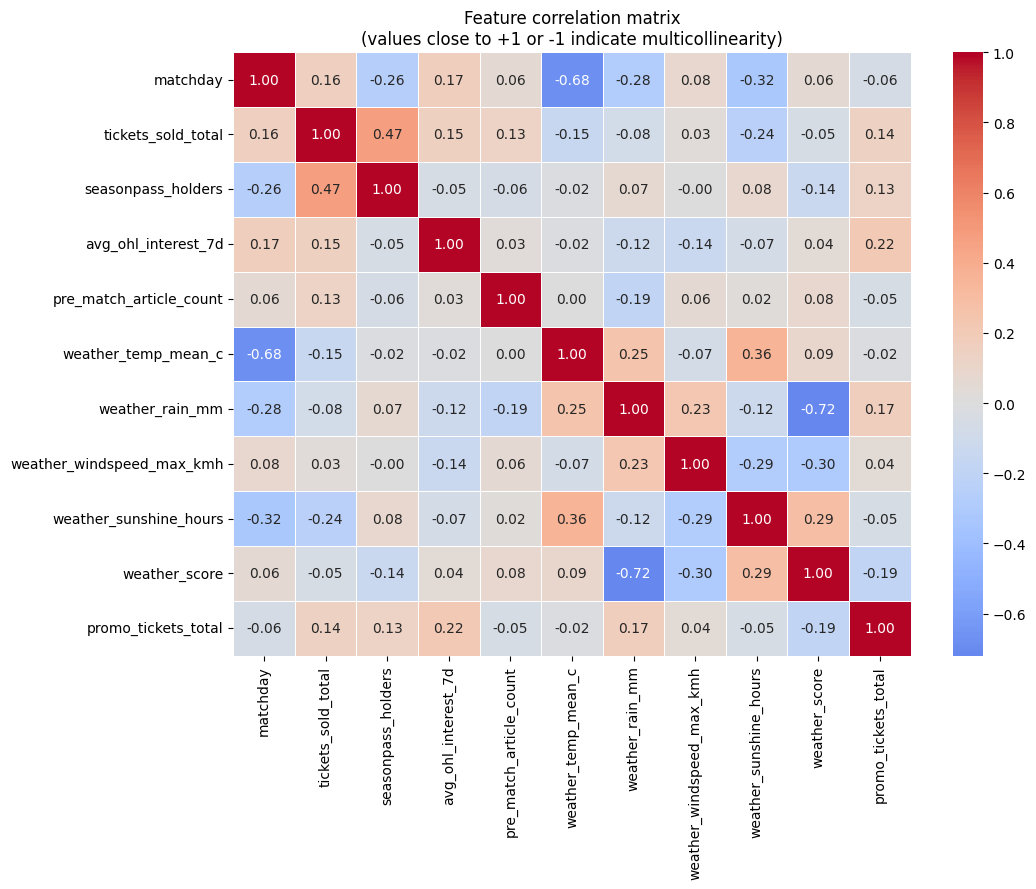

In [31]:
# Correlation matrix between features — shows WHY the VIF is high
corr_matrix = vif_data.corr().round(2)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature correlation matrix\n(values close to +1 or -1 indicate multicollinearity)')
plt.tight_layout()
plt.show()

## 11. Feature Importance — Training a Random Forest model
First we train a Random Forest model. Then we calculate in two ways which features contribute most to the prediction:
- **Permutation Importance** — how much does accuracy drop when we randomly shuffle one feature?
- **SHAP values** — for each match individually: how much did each feature push the prediction up or down?

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# Prepare features
model_df = df.copy()

# Add categorical columns
model_df['away_team'] = match.set_index('match_id')['away_team'].reindex(model_df['match_id'].values).values
model_df['stage']     = match.set_index('match_id')['stage'].reindex(model_df['match_id'].values).values
model_df['season']    = match.set_index('match_id')['season'].reindex(model_df['match_id'].values).values

# Encode categorical columns to numbers
model_df['away_team_enc'] = model_df['away_team'].astype('category').cat.codes
model_df['stage_enc']     = model_df['stage'].astype('category').cat.codes
model_df['season_enc']    = model_df['season'].str[:4].astype(int)

# Encode boolean columns to 0/1
bool_cols = ['is_weekend', 'is_midweek', 'is_public_holiday', 'is_school_holiday_flanders', 'has_promotion']
for col in bool_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].map({True: 1, False: 0, 'true': 1, 'false': 0}).fillna(0)

# Select all features for the model
feature_cols = [
    'matchday', 'tickets_sold_total', 'seasonpass_holders',
    'avg_ohl_interest_7d', 'pre_match_article_count',
    'weather_temp_mean_c', 'weather_rain_mm', 'weather_windspeed_max_kmh',
    'weather_sunshine_hours', 'weather_score', 'promo_tickets_total',
    'away_team_enc', 'stage_enc', 'season_enc',
    'is_weekend', 'is_school_holiday_flanders', 'has_promotion'
]

feature_cols = [c for c in feature_cols if c in model_df.columns]

model_data = model_df[feature_cols + ['tickets_scanned']].dropna()
X = model_data[feature_cols]
y = model_data['tickets_scanned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
print(f"R²:  {r2_score(y_test, preds):.3f}")
print(f"MAE: {mean_absolute_error(y_test, preds):.0f} tickets")

R²:  0.367
MAE: 1004 tickets


## 12. Permutation Importance
Each feature is shuffled randomly one by one. The stronger the R² drops = the more important that feature is.

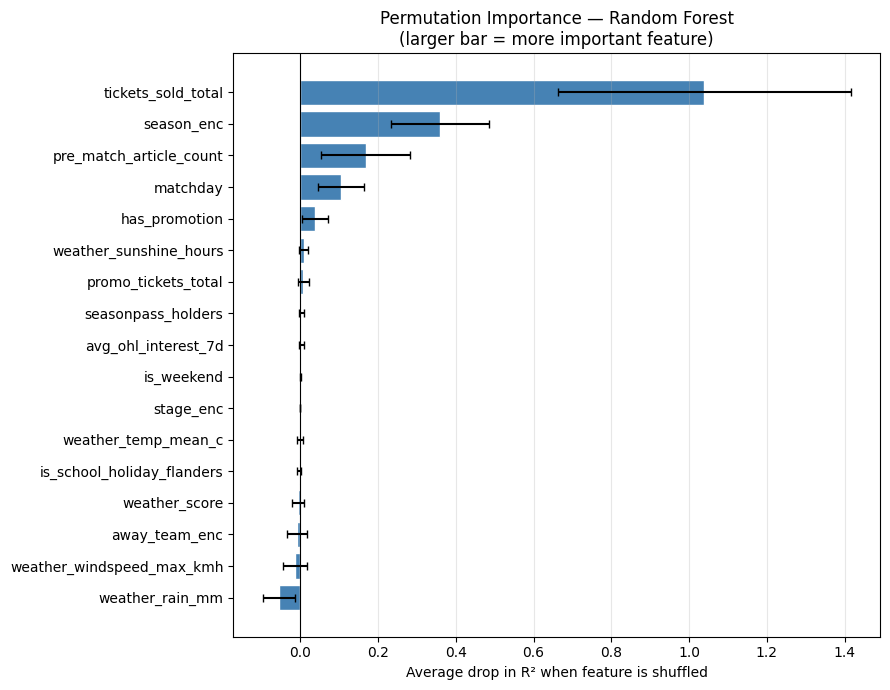

                   feature  importance
        tickets_sold_total    1.038655
                season_enc    0.359617
   pre_match_article_count    0.168901
                  matchday    0.105221
             has_promotion    0.038657
    weather_sunshine_hours    0.008802
       promo_tickets_total    0.007945
        seasonpass_holders    0.002691
       avg_ohl_interest_7d    0.002400
                is_weekend    0.000990
                 stage_enc    0.000000
       weather_temp_mean_c   -0.000568
is_school_holiday_flanders   -0.002175
             weather_score   -0.006388
             away_team_enc   -0.009064
 weather_windspeed_max_kmh   -0.012377
           weather_rain_mm   -0.054352


In [33]:
perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)

perm_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color='steelblue', edgecolor='white', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Average drop in R² when feature is shuffled')
ax.set_title('Permutation Importance — Random Forest\n(larger bar = more important feature)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(perm_df[['feature','importance']].sort_values('importance', ascending=False).to_string(index=False))

## 13. SHAP Values
SHAP explains per match why the model made that specific prediction.
- **Positive SHAP value** → this feature pushed the prediction up
- **Negative SHAP value** → this feature pushed the prediction down

Install SHAP if needed: `pip install shap`

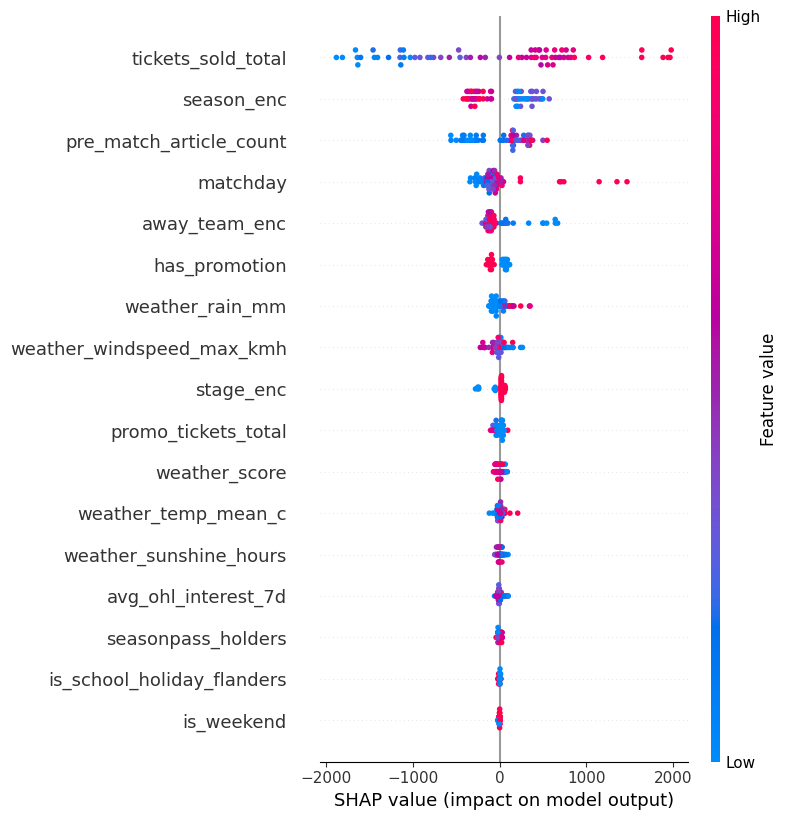

In [34]:
import shap

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Beeswarm plot — shows SHAP value per feature per match
shap.summary_plot(shap_values, X, plot_type='dot', show=True)

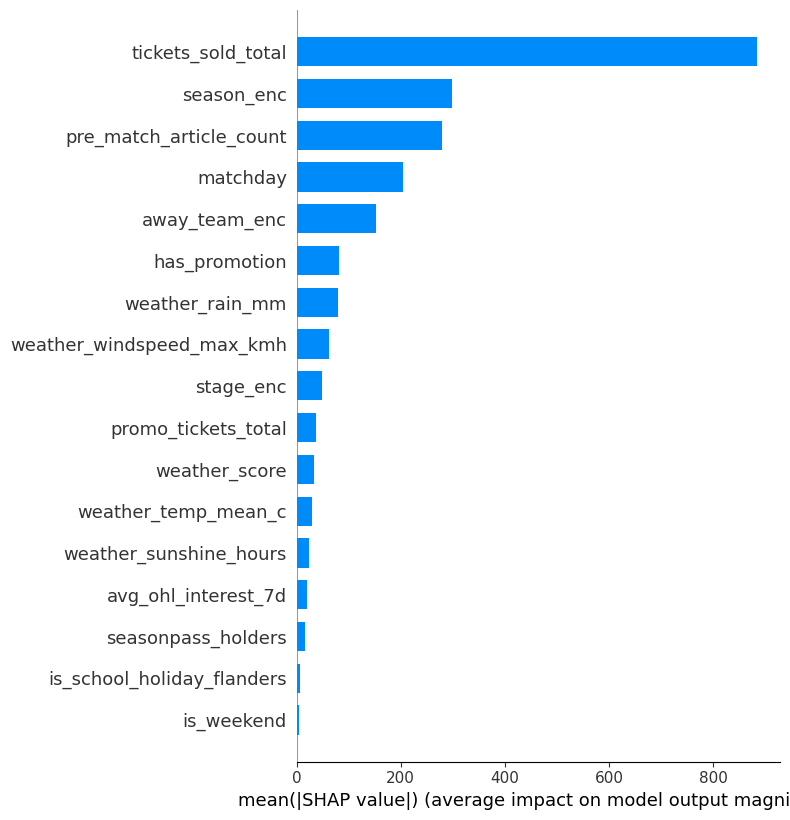

In [35]:
# Bar plot — mean absolute SHAP value per feature (global ranking)
shap.summary_plot(shap_values, X, plot_type='bar', show=True)